# TAD Borders Analysis for Non-Neurons

Analysis of TAD border clustering and PCA for non-neuronal cells.

In [ ]:
import os
from os import listdir
from os.path import isfile, join, basename
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cooler
import cooltools.lib.plotting
from cooltools import insulation
import cooltools
import seaborn as sns
from packaging import version
import collections
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import bioframe
import bioframe as bf
from pybedtools import BedTool as pbt
import bbi
from tqdm import tqdm
from adjustText import adjust_text
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import fclusterdata
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.express as px
import gseapy as gp
from gseapy import barplot, dotplot
from scipy.stats import mannwhitneyu, ttest_ind
from statsmodels.stats.multitest import fdrcorrection
from dotenv import load_dotenv
import matplotlib as mpl

if version.parse(cooltools.__version__) < version.parse('0.5.1'):
    raise AssertionError("tutorials rely on cooltools version 0.5.1 or higher, please check your cooltools version and update to the latest")

plt.rcParams['font.size'] = 12

In [84]:
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Helvetica'
mpl.rc('lines', linewidth=0.4)
mpl.rc('font', family='Helvetica', size=8)
mpl.rc('axes', labelsize=8, titlesize=8, linewidth=0.4)
mpl.rc('legend', fontsize=8)
mpl.rc('xtick', labelsize=6)
mpl.rc('xtick.major', width=0.4, size=2)
mpl.rc('xtick.minor', width=0.4, size=1)
mpl.rc('ytick', labelsize=6)
mpl.rc('ytick.major', width=0.4, size=2)
mpl.rc('ytick.minor', width=0.4, size=1)

## 0. Prepare files for bigwigs

In [87]:
for file in tqdm(insulation_score_datasets):
    name = file.split(res)[0].split('full_insulation_score_')[1]
    print(name)    
    df =pd.read_csv(f"{path_to_tads}/{file}",sep=",")
    df =  df[['chrom', 'start', 'end', 'log2_insulation_score_150000']][~ df[['chrom', 'start', 'end', 'log2_insulation_score_150000']].log2_insulation_score_150000.isna()]
    df.to_csv(f"{path_to_tads}/main_files_reduced_full_insulation_tables/{file.split('.csv')[0]}",index=False, header=None, sep='\t')



  0%|                                                                                                                                                             | 0/12 [00:00<?, ?it/s]

HC-2Mminus_sampled_drop_diag


  8%|████████████▍                                                                                                                                        | 1/12 [00:00<00:08,  1.36it/s]

HC-318minus_drop_diag_1kb


 17%|████████████████████████▊                                                                                                                            | 2/12 [00:01<00:06,  1.44it/s]

...

 83%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                        | 10/12 [00:06<00:01,  1.51it/s]

SZ20minus_sampled_drop_diag


 92%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋            | 11/12 [00:07<00:00,  1.52it/s]

SZ6minus_sampled_drop_diag


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [00:07<00:00,  1.50it/s]


In [ ]:
load_dotenv()

path_to_maps = os.getenv("PATH_TO_PROCESSED_MAPS")
path_to_save = "./glia_tads_borders_layouts/"
    
resolution_kb = 15 
res = f"_{resolution_kb}res"
insulation_score_datasets = [f for f in listdir(path_to_save) if "full_insulation_score_" in f]
insulation_score_datasets = [f for f in insulation_score_datasets if "15res" in f and '150wind' in f]
insulation_score_datasets = [f for f in insulation_score_datasets if "merge" not in f]

insulation_score_datasets.sort()
df_res_final = create_pca_table(insulation_score_datasets, path_to_save, save_name = 'pca_res_15res_150wind')

In [93]:
dfs = {}
for file in tqdm(insulation_score_datasets):
    name = file.split(res)[0].split('full_insulation_score_')[1]
    print(name)        
    dfs[name] =pd.read_csv(f"./glia_tads_borders_layouts//{file}",sep=",")

  8%|████████████▍                                                                                                                                        | 1/12 [00:00<00:01,  5.57it/s]

HC-2Mminus_sampled_drop_diag
HC-318minus_drop_diag_1kb


 25%|█████████████████████████████████████▎                                                                                                               | 3/12 [00:00<00:01,  5.57it/s]

HC-3Mminus_sampled_drop_diag
HC-91minus_sampled_drop_diag


 42%|██████████████████████████████████████████████████████████████                                                                                       | 5/12 [00:00<00:01,  5.60it/s]

...

 75%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████▊                                     | 9/12 [00:01<00:00,  5.49it/s]

SZ08minus_sampled_drop_diag
SZ10minus_sampled_drop_diag


 92%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋            | 11/12 [00:01<00:00,  5.46it/s]

SZ20minus_sampled_drop_diag
SZ6minus_sampled_drop_diag


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [00:02<00:00,  5.51it/s]


In [94]:
tad_border_number = {}
for name in dfs.keys():
    tad_border_number[name] = dfs[name][dfs[name]['is_boundary_150000'] == True].shape[0]
len(tad_border_number)

12

In [95]:
def abline(slope, intercept):
    axes = plt.gca()
    x_vals = np.array(axes.get_xlim())
    y_vals = intercept + slope * x_vals
    plt.plot(x_vals, y_vals, '--')
     
def make_pca_on_df(df_res_final, save_name, remove_three_columns=True):
    if remove_three_columns:
        df_columns = df_res_final.columns.tolist()[3:]
        prep_df = df_res_final[df_res_final.columns.tolist()[3:]].T.reset_index().fillna(0)
    else:
        df_columns = df_res_final.columns.tolist()
        prep_df = df_res_final[df_res_final.columns.tolist()].T.reset_index().fillna(0)

    X = prep_df[prep_df.columns.tolist()[1:]]
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X)
    pca = PCA(n_components=6)
    components = pca.fit_transform(X_train_scaled)
    
    components_df = pd.DataFrame(components, columns = ["PC1","PC2","PC3","PC4","PC5","PC6"])
    if remove_three_columns:
        components_df["sample"] =df_res_final.T.reset_index()["index"].tolist()[3:]
    else:
        components_df["sample"] =df_res_final.T.reset_index()["index"].tolist()
    components_df["sample"] = ["PsychENCODE" if 'psychencode_iPCS_NeuNplus' in i else i for i in components_df["sample"].tolist()]

    
    group = []
    for i in df_columns :
        if 'SZ' in i:
            group.append('SZ')
        else:
            group.append('HC')
    assert len(group) == len(df_columns) 
    components_df['group'] = group
    
    sample_simple = []
    for i in components_df["sample"] :
        sample_simple.append(i.split('_')[0])
    components_df['sample_simple'] =sample_simple
    
    if save_name:
        components_df.to_csv(f'./glia_tads_additional_files/{save_name}.tsv', index=False, sep='\t')
    return components_df, pca


def plot_pca_main(pca, components_df, compontents, hue='group', min_v=-300, max_v=500, use_min_max = True, save_name=None):
    sns.set_style("white")
    plt.figure(figsize=(6,6)) 
    my_pal = {"SZ": (sns.color_palette('deep')[8]),
              "HC": (sns.color_palette('deep')[4])}


    sns.scatterplot(data=components_df, s=120, x=compontents[0], y=compontents[1], 
                    hue=hue,edgecolor='black',
                    palette = my_pal)
    
    abline(0, 0)    
    plt.axvline(0, 0,300, ls = '--', c = "lightgrey")
    plt.axhline(0, 0,300, ls = '--', c = "lightgrey")
    if use_min_max: 
        plt.ylim(min_v,max_v)
        plt.xlim(min_v,max_v)
    plt.legend(frameon=True, loc='best')
    PCA_order = {"PC1":0, "PC2":1, "PC3":2}
    plt.xlabel(f"{compontents[0]} {round(pca.explained_variance_ratio_[PCA_order[compontents[0]]].round(3)*100,1)}%")
    plt.ylabel(f"{compontents[1]} {round(pca.explained_variance_ratio_[PCA_order[compontents[1]]].round(3)*100,1)}%")
    
    texts = [plt.text(components_df[compontents[0]][line], components_df[compontents[1]][line], components_df["sample_simple"][line], horizontalalignment='left',
                  size='small', color='black')
             for line in range(0,components_df.shape[0])]
    adjust_text(texts, arrowprops=dict(arrowstyle="-", color='k', lw=0.4))
    plt.legend(bbox_to_anchor=(1.9, 1.05))
    if save_name:
        plt.savefig(f'./glia_tads_visualizations/{save_name}.pdf', dpi=600, bbox_inches='tight', format='pdf')
    plt.show()

In [96]:
components_df, pca = make_pca_on_df(df_res_final, "tadBorders_PCA_data")
print(pca.explained_variance_ratio_)

[0.11427218 0.10509947 0.09244997 0.09078153 0.08924632 0.08812526]


               In some cases adjust_text might fail, if possible update
               matplotlib to version >=3.5.0


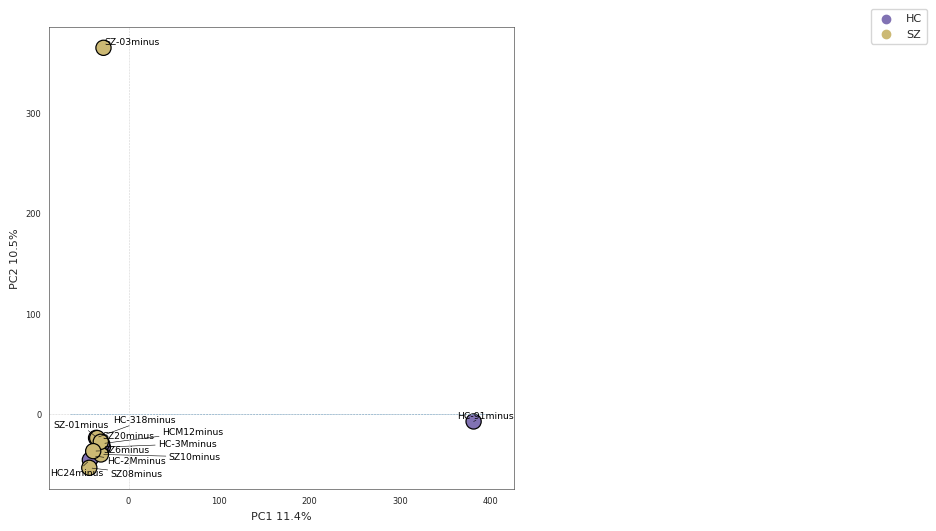

               In some cases adjust_text might fail, if possible update
               matplotlib to version >=3.5.0


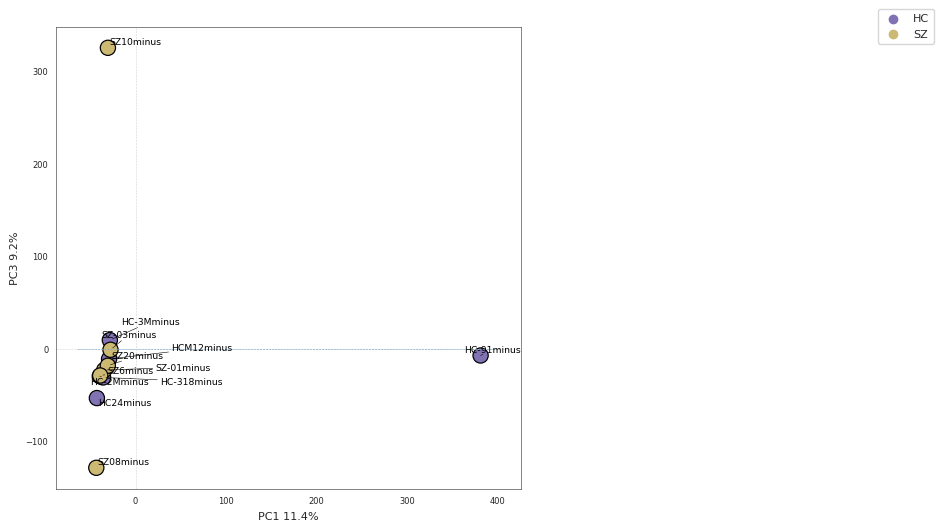

               In some cases adjust_text might fail, if possible update
               matplotlib to version >=3.5.0


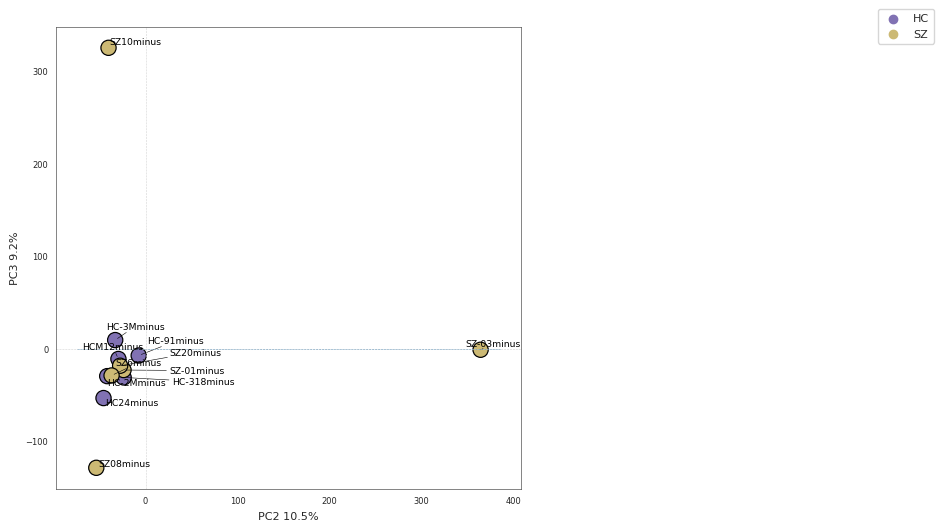

In [97]:
for pca_sel in [['PC1','PC2'], ['PC1','PC3'],['PC2','PC3']]:
    plot_pca_main(pca, components_df, pca_sel, hue ="group", use_min_max=False, min_v=-150, max_v = 400, save_name=None)

## 3. TADs borders clusterization

In [98]:
def check_merge_effects(merged_bedpe_clf_2_5):
    #1
    description = "The number of borders in one Cluster from one Source"
    df_check = merged_bedpe_clf_2_5.groupby(['cluster', 'source']).size().to_frame().reset_index()
    print(description, df_check.groupby(0).size().to_frame())
    print("__"*14)
    
    #2
    description = "The MAX number of borders in all Cluster - "
    print(description, merged_bedpe_clf_2_5.groupby(['cluster']).size().max())
    print("__"*14)
    
    #3
    description = "The number of Clusters by the borders from different Sources "
    df_check["diff_sources"] = 1
    print(description, df_check.groupby(['cluster', "diff_sources"]).size().to_frame().groupby(0).size())
    print("__"*14)

    #4
    description = "The number of Clusters with the specific size"
    print(description, merged_bedpe_clf_2_5.groupby(['cluster']).size().to_frame().reset_index().groupby(0).size())
    
def merge_bed(df, res=15000, cluster_factor = 2, dist_method='cityblock', min_pts=3):
    bedpe = df.copy() 
    bedpe = bedpe.fillna(0)
    chr_bedpe = {k: v for k, v in bedpe.groupby(bedpe.iloc[:, 0])}
    for chrom in tqdm(chr_bedpe):
        coords = chr_bedpe[chrom].iloc[:, [1, 2]].values
        dist_matrix = squareform(pdist(coords, metric=dist_method))
        clustering = DBSCAN(eps=int(res*cluster_factor), min_samples=min_pts, metric='precomputed').fit(dist_matrix)
        chr_bedpe[chrom]['cluster'] = clustering.labels_  
    for chrom in chr_bedpe:
        chr_bedpe[chrom]['cluster'] = [chrom+"_"+str(i) for i in chr_bedpe[chrom]['cluster']]
    merged_bedpe = pd.concat(chr_bedpe.values(), ignore_index=True)
    return bedpe, merged_bedpe

def create_merged_bed(insulation_score_datasets):
    bed = []
    columns = ['chrom', 'start', 'end', 'boundary_strength_150000']
    for dataset in insulation_score_datasets:
        if "Lu2020" not in dataset:
            df = pd.read_csv(dataset)
            df = df[df.is_boundary_150000 == True][columns]
            df.reset_index(drop=True, inplace=True)        
            dataset_name = ("_").join(dataset.split("/")[-1].split("_")[3:9])            
            cnt = 0
            for i in samples2groups.keys():
                if i in dataset_name:
                    if i == "Rahman2023" and "iPSC" in dataset_name:
                        continue
                    else:
                        print(i, dataset_name)
                        dataset_name = i                    
                    cnt+=1            
            assert cnt == 1                    
            df['source'] = basename(dataset_name)
            bed.append(df)  
        else:
            print(f"Remove {dataset} from the analysis")
    bed = pd.concat(bed, ignore_index=True)
    return bed
    

In [100]:
groups = [k for i,k in samples2groups.items()]
counter = collections.Counter(groups)
counter

Counter({'HC': 6, 'SZ': 6})

In [101]:
bed = create_merged_bed(insulation_score_datasets)
df_res_final_clusters, merged_bed = merge_bed(bed, res=15000, cluster_factor = 2, dist_method='cityblock', min_pts=3)

HC-2Mminus_sampled_drop_diag_15res_150wind.csv HC-2Mminus_sampled_drop_diag_15res_150wind.csv
HC-318minus_drop_diag_1kb_15res_150wind.csv HC-318minus_drop_diag_1kb_15res_150wind.csv
HC-3Mminus_sampled_drop_diag_15res_150wind.csv HC-3Mminus_sampled_drop_diag_15res_150wind.csv
HC-91minus_sampled_drop_diag_15res_150wind.csv HC-91minus_sampled_drop_diag_15res_150wind.csv
HC24minus_sampled_drop_diag_15res_150wind.csv HC24minus_sampled_drop_diag_15res_150wind.csv
HCM12minus_sampled_drop_diag_15res_150wind.csv HCM12minus_sampled_drop_diag_15res_150wind.csv
SZ-01minus_sampled_drop_diag_15res_150wind.csv SZ-01minus_sampled_drop_diag_15res_150wind.csv
SZ-03minus_sampled_drop_diag_15res_150wind.csv SZ-03minus_sampled_drop_diag_15res_150wind.csv
SZ08minus_sampled_drop_diag_15res_150wind.csv SZ08minus_sampled_drop_diag_15res_150wind.csv
SZ10minus_sampled_drop_diag_15res_150wind.csv SZ10minus_sampled_drop_diag_15res_150wind.csv
SZ20minus_sampled_drop_diag_15res_150wind.csv SZ20minus_sampled_drop_dia

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 24/24 [00:12<00:00,  1.96it/s]


In [104]:
check_merge_effects(merged_bed)

The number of borders in one Cluster from one Source          0
0         
1    61343
2        2
4        1
5        2
6        3
..     ...
101      1
103      1
109      2
112      3
131      1

[88 rows x 1 columns]
____________________________
The MAX number of borders in all Cluster -  960
____________________________
The number of Clusters by the borders from different Sources  0
3     1008
4      645
5      464
6      426
7      398
8      399
9      474
10     497
11     791
12    2269
dtype: int64
____________________________
The number of Clusters with the specific size 0
3      1008
4       644
5       464
6       426
7       398
8       399
9       474
10      497
11      791
12     2246
56        1
91        1
116       1
120       1
176       1
179       1
210       1
228       1
275       1
317       1
340       1
398       1
444       1
463       1
464       1
488       1
535       1
607       1
702       1
715       1
779       1
796       1
925       1
960       1
dty

In [105]:
def create_dataframe(comparisons_all, col_name, stat_col):
    comparisons_all = pd.DataFrame(comparisons_all).T.reset_index()
    comparisons_all.rename(columns = {"index":col_name}, inplace= True)
    
    normalized_dfs = pd.DataFrame()
    for column in comparisons_all.columns[1:]:  # Skip the first column 'border_num'
        temp_df = pd.json_normalize(comparisons_all[column]).reset_index(drop=True)
        temp_df.columns = [f"{column}_{subcol}" for subcol in temp_df.columns]
        print(f"Columns - {temp_df.columns}")
        normalized_dfs = pd.concat([normalized_dfs, temp_df],axis=1).reset_index(drop=True)
    
    result_df = pd.concat([comparisons_all[[col_name]] , normalized_dfs], axis=1)
    
    return result_df
    
def get_cluster_data_clustering(df, make_stats=True, dict_counter = counter , dict_sample_to_group = samples2groups, feature_column = 'cluster', remove_heffel_infant = False):
    unique_features = df[feature_column].unique()
    unique_sources = df["source"].unique()
    unique_states = list(set(dict_sample_to_group.values()))
    
    features_all, t_stat_all, p_value_all = [], [], []
    comparisons_all = {}
    all_clusters_data = {}
    for feature in tqdm(unique_features):
        all_clusters_data[feature] = {}
        data = df[df['cluster'] == feature]
        state_values_all = {}
        for state in list(set(dict_sample_to_group.values())):
            filtered_dictionary = {i:k for i,k in dict_sample_to_group.items() if k ==state and "Lu2020" not in i }
            state_values = []
            for source in filtered_dictionary.keys(): 
                data_specific_source = data[data.source == source].sort_values("boundary_strength_150000", ascending=False)
                if data_specific_source.shape[0]>0:
                    state_values.append(data_specific_source.boundary_strength_150000.iloc[0])
                    all_clusters_data[feature][source] = data_specific_source.boundary_strength_150000.iloc[0]
                else:
                    state_values.append(0)
                    all_clusters_data[feature][source] = 0
            if not remove_heffel_infant :
                assert len(state_values) == dict_counter[state]
            state_values_all[state] = state_values  
      
        if make_stats:
            comparisons = {}
            starter = 0
            keys = list(dict_counter.keys())
            n = len(keys)
            for i_init in range(n):
                for j_init in range(i_init+1, n):
                    i = keys[i_init]
                    j = keys[j_init]                    
                    comparisons[i+"_vs_"+j] = {}
                    starter+=1
                    group1 = state_values_all[i]
                    group2 = state_values_all[j]
                    # t_stat, p_value = ttest_ind(group1, group2, equal_var=False)
                    mu_stat, p_value = mannwhitneyu(group1, group2, nan_policy ='omit') 
                    # comparisons[i+"_vs_"+j]['t_stat'] = t_stat
                    comparisons[i+"_vs_"+j]['mu_stat'] = mu_stat
                    comparisons[i+"_vs_"+j]['p_value'] = p_value
    
            comparisons_all[feature] = comparisons

    comparisons_all = create_dataframe(comparisons_all, feature_column, stat_col = 'p_value')
    return comparisons_all, all_clusters_data, comparisons

def rename_all_clusters_data(all_clusters_data, samples2groups):
    all_clusters_data = pd.DataFrame(all_clusters_data).T
    for old_name in all_clusters_data.columns: 
        if samples2groups.get(old_name):
            new_name = old_name+"_"+samples2groups[old_name]
            all_clusters_data.rename(columns = {old_name:new_name}, inplace=True)
    return all_clusters_data

In [106]:
counter = {'HC': 7, 'SZ': 7}

keys = list(counter.keys())
n = len(keys)
for i_init in range(n):
    for j_init in range(i_init+1, n):
        i = keys[i_init]
        j = keys[j_init]
        print(i,j)
        

HC SZ


In [108]:
merged_bed = merged_bed[['chrom', 'start', 'end', 'boundary_strength_150000', 'source', 'cluster']].merge(comparisons_all_clusters, on = "cluster")
merged_bed.dropna(inplace = True)
merged_bed = merged_bed[~merged_bed.cluster.map(lambda x: "_-1" in x)]
merged_bed.to_pickle("./tads_additional_files_non_neurons/merged_bed_with_tads_clustering_non_neurons.pickle")

In [110]:
all_clusters_data = rename_all_clusters_data(all_clusters_data, samples2groups)
components_df, pca = make_pca_on_df(all_clusters_data, "tadBorders_PCA_data_15res_150wind_non_neurons", remove_three_columns=False)
pca.explained_variance_ratio_

array([0.15606188, 0.09372564, 0.09268488, 0.09038431, 0.08840601,
       0.0868976 ])

               In some cases adjust_text might fail, if possible update
               matplotlib to version >=3.5.0


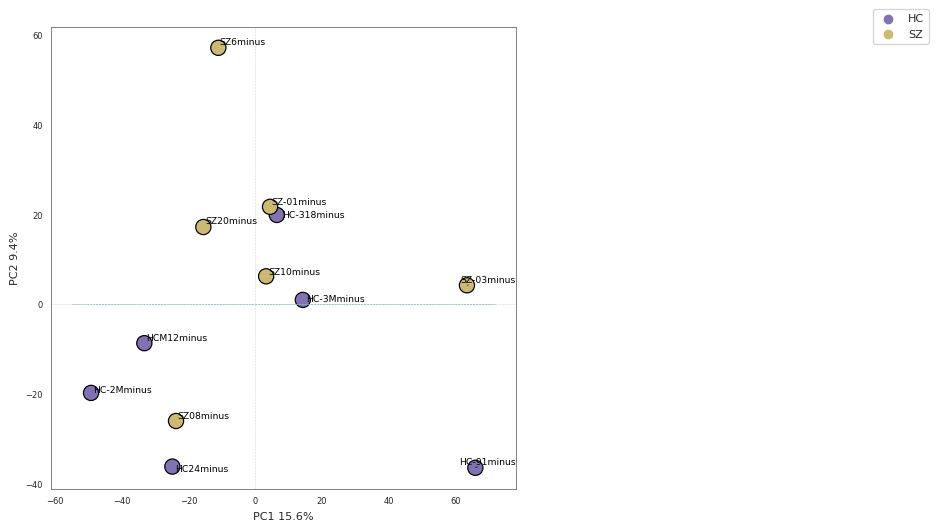

               In some cases adjust_text might fail, if possible update
               matplotlib to version >=3.5.0


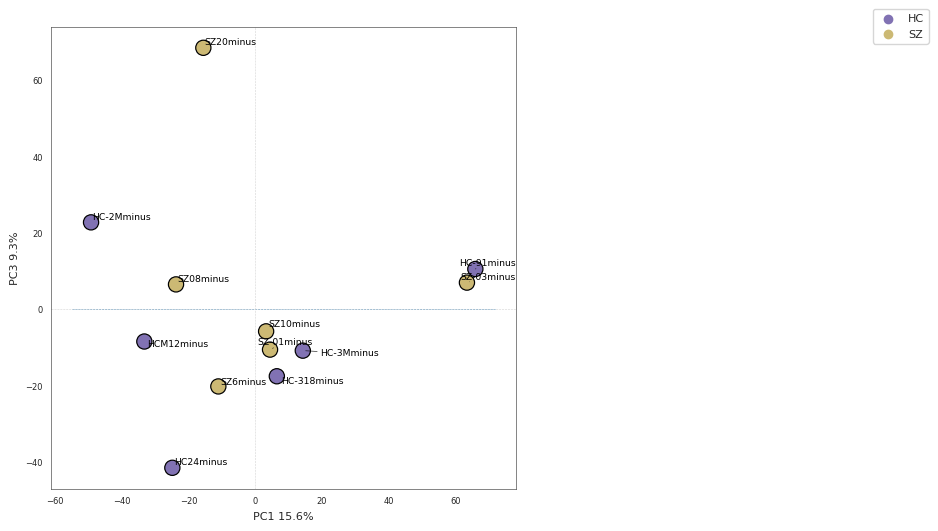

               In some cases adjust_text might fail, if possible update
               matplotlib to version >=3.5.0


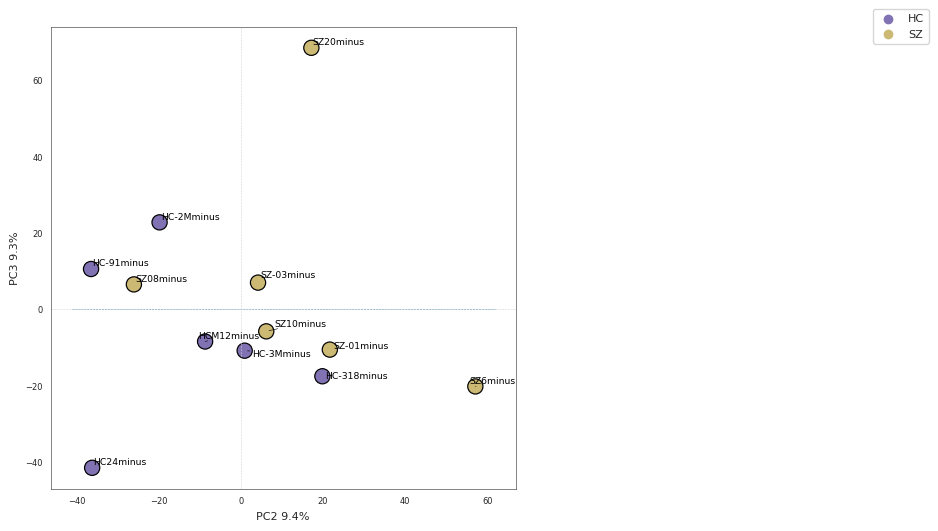

In [111]:
for pca_sel in [['PC1','PC2'], ['PC1','PC3'],['PC2','PC3']]:
    plot_pca_main(pca, components_df, pca_sel, use_min_max=False, min_v=-550, max_v = 790, save_name=None)